# Atividade: CNNs para Classificação

Neste notebook, iremos preparar nosso próprio dataset e treinar um modelo de classificação de imagens.

## Preparando os dados

Os dados desta atividade serão baixados da internet. Utilizaremos para isso buscadores comuns. Em seguida, dividiremos em treinamento e validação.

In [20]:
!pip install icrawler

In [21]:
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
import time
import copy
import matplotlib.pyplot as plt
import numpy as np

from icrawler.builtin import GoogleImageCrawler, BingImageCrawler
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler

### Adquirindo as Imagens

Utilizaremos o iCrawler para baixar imagens em buscadores através de termos especificados. Defina sua lista de classes.

In [22]:
# def download_images(keyword, folder, n_total=100):
#     os.makedirs(folder, exist_ok=True)
#     downloaded = len(os.listdir(folder))
#     remaining = n_total - downloaded

#     while downloaded < n_total:
#         crawler = GoogleImageCrawler(storage={'root_dir': folder})
#         crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
#         downloaded = len(os.listdir(folder))
#         remaining = n_total - downloaded
#         print(f"Downloaded {downloaded}/{n_total}")

#     print("Download complete!")

def download_images(keyword, folder, n_total=300):
    os.makedirs(folder, exist_ok=True)

    # Verifica quantas imagens já existem para não baixar duplicado se rodar de novo
    downloaded = len([name for name in os.listdir(folder) if os.path.isfile(os.path.join(folder, name))])
    remaining = n_total - downloaded

    if remaining <= 0:
        print(f"Já existem {downloaded} imagens em {folder}. Pulando...")
        return

    # MUDANÇA AQUI: Trocamos GoogleImageCrawler por BingImageCrawler
    crawler = BingImageCrawler(storage={'root_dir': folder})

    # O BingCrawler às vezes precisa de filters=None explicitamente ou roda direto
    crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)

    final_count = len(os.listdir(folder))
    print(f"Download concluído! Total na pasta: {final_count}")



In [23]:
# search_terms = {
#     "vader": "darth vader", # nome da classe: termo que será usado na busca
# }

# for label, term in search_terms.items():
#     download_images(term, f"data/star_wars/{label}", n_total=100)

### Treinamento e Validação

Dividiremos as imagens baixadas nas pastas `train` e `val`. Defina uma porcentagem.

In [24]:
def split_train_val(root_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    train_dir = root_dir + "_split/train"
    val_dir = root_dir + "_split/val"

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f) for f in os.listdir(class_path)]
        images = [f for f in images if os.path.isfile(f)]
        random.shuffle(images)

        n_train = int(len(images) * train_ratio)

        train_class_dir = os.path.join(train_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in images[:n_train]:
            shutil.copy(img, os.path.join(train_class_dir, os.path.basename(img)))
        for img in images[n_train:]:
            shutil.copy(img, os.path.join(val_class_dir, os.path.basename(img)))

        print(f"{class_name}: {n_train} train, {len(images)-n_train} val")

# Minha resolução:

## Adquirindo imagens:

In [25]:
# Definição dos termos de busca
search_terms = {
    "rose": "rose plant",
    "margriet": "margriet plant",
    "sunflower": "sunflower plant"
}

# Pasta base para salvar as imagens
base_dataset_folder = "data/flowers"

# Loop para baixar as imagens de cada classe
for label, term in search_terms.items():
    print(f"Baixando imagens para: {label} ({term})")
    # Baixa 100 imagens por classe
    download_images(term, f"{base_dataset_folder}/{label}", n_total=100)

Baixando imagens para: rose (rose plant)


ERROR:downloader:Response status code 403, file https://garden.org/pics/2021-02-02/AnnKNCalif/8851e8.jpg
ERROR:downloader:Response status code 403, file https://garden.org/pics/2020-06-09/AnnKNCalif/e0ab4e.jpg
ERROR:downloader:Response status code 403, file https://c.pxhere.com/photos/98/a8/roses_garden_rosebush_bloom_summer_rose_flower_nature_flower-666474.jpg
ERROR:downloader:Response status code 403, file https://garden.org/pics/2016-10-18/Rebekah/e5f6ad.jpg


Download concluído! Total na pasta: 96
Baixando imagens para: margriet (margriet plant)


ERROR:downloader:Response status code 404, file https://i0.wp.com/goede-planten.nl/wp-content/uploads/2022/12/Gewone-margriet_4-IMG_8629.jpg
ERROR:downloader:Response status code 404, file https://i0.wp.com/goede-planten.nl/wp-content/uploads/2022/12/Gewone-margriet_1-1024x684.jpg
ERROR:downloader:Response status code 404, file https://plantenvanhier.nl/____impro/1/onewebmedia/Gewone margriet met Gouden tor.jpg
ERROR:downloader:Exception caught when downloading file https://www.planten.floraeuropa.eu/images/stories/virtuemart/product/Leucanthemum vulgare (10).jpg, error: HTTPSConnectionPool(host='www.planten.floraeuropa.eu', port=443): Max retries exceeded with url: /images/stories/virtuemart/product/Leucanthemum%20vulgare%20(10).jpg (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate (_ssl.c:1010)'))), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://www.planten.flo

Download concluído! Total na pasta: 86
Baixando imagens para: sunflower (sunflower plant)


ERROR:downloader:Response status code 403, file https://gilmour.com/wp-content/uploads/2018/03/growing-sunflowers.jpg


Download concluído! Total na pasta: 62


## Treinamento e Validação:

In [26]:
# Após baixar, realizamos a divisão entre treino e validação
print("\nDividindo dataset em Treino e Validação...")
split_train_val(base_dataset_folder, train_ratio=0.8)


Dividindo dataset em Treino e Validação...
sunflower: 49 train, 13 val
rose: 76 train, 20 val
margriet: 68 train, 18 val


## Dataset

Implemente um Dataset PyTorch que carregue as imagens baixadas com suas respectivas classes. Aplique data augmentation e carregue em batches.

In [27]:
# Transformações: Data Augmentation para treino e normalização padrão para ambos
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),     # Redimensiona para o input da ResNet
        transforms.RandomHorizontalFlip(), # Data Augmentation simples
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Média e Desvio padrão do ImageNet
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = f"{base_dataset_folder}_split" # A pasta criada pela função split_train_val

# Criação dos Datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

# Criação dos DataLoaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
               for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Classes encontradas: {class_names}")
print(f"Tamanho dos datasets: {dataset_sizes}")
print(f"Utilizando dispositivo: {device}")

Classes encontradas: ['margriet', 'rose', 'sunflower']
Tamanho dos datasets: {'train': 214, 'val': 74}
Utilizando dispositivo: cuda:0


## Definição do Modelo

Defina aqui o modelo que será utilizado, sendo implementação própria ou um modelo pré-treinado. Teste diversas arquiteturas diferentes e verifique qual delas tem melhor desempenho em validação.

In [34]:
# Carrega a ResNet18 com pesos aprendidos no ImageNet
model_ft = models.resnet18(pretrained=True)

# (Opcional) Congelar as camadas iniciais para treinar apenas o final
for param in model_ft.parameters():
    param.requires_grad = False

# Número de features na entrada da última camada (fc)
num_ftrs = model_ft.fc.in_features

# Substitui a última camada (que tinha 1000 classes) por uma com 3 classes (nossas flores)
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

# Envia o modelo para a GPU se disponível
model_ft = model_ft.to(device)

## Treinamento

Defina a função de custo e o otimizador do modelo. Em seguida, implemente o código de treinamento e treine-o. Ao final, exiba as curvas de treinamento e validação para a loss e a acurácia.

In [35]:
# Função de erro: Cross Entropy Loss (padrão para classificação)
criterion = nn.CrossEntropyLoss()

# Otimizador: SGD com momentum (pode testar Adam também)
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Scheduler: Reduz a learning rate a cada 7 épocas
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Para plotar gráficos depois
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Cada época tem fase de treino e validação
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Itera sobre os dados
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + Optimize apenas no treino
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Salva histórico
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy do modelo se for o melhor até agora
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Treinamento completo em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Melhor Acurácia Val: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

# Executa o treinamento
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 1.1097 Acc: 0.3551
val Loss: 0.9668 Acc: 0.5000

Epoch 1/9
----------
train Loss: 0.7998 Acc: 0.7290
val Loss: 0.6199 Acc: 0.9459

Epoch 2/9
----------
train Loss: 0.5468 Acc: 0.8785
val Loss: 0.4127 Acc: 0.9730

Epoch 3/9
----------
train Loss: 0.3529 Acc: 0.9439
val Loss: 0.3113 Acc: 0.9730

Epoch 4/9
----------
train Loss: 0.2957 Acc: 0.9533
val Loss: 0.2428 Acc: 0.9730

Epoch 5/9
----------
train Loss: 0.2206 Acc: 0.9766
val Loss: 0.2049 Acc: 0.9730

Epoch 6/9
----------
train Loss: 0.2016 Acc: 0.9766
val Loss: 0.1817 Acc: 0.9730

Epoch 7/9
----------
train Loss: 0.1810 Acc: 0.9720
val Loss: 0.1809 Acc: 0.9730

Epoch 8/9
----------
train Loss: 0.1775 Acc: 0.9813
val Loss: 0.1787 Acc: 0.9730

Epoch 9/9
----------
train Loss: 0.1918 Acc: 0.9720
val Loss: 0.1760 Acc: 0.9730

Treinamento completo em 2m 14s
Melhor Acurácia Val: 0.972973


## Inferência

Calcule algumas métricas como acurácia, matriz de confusão, etc. Em seguida, teste o modelo em novas imagens das classes correspondentes mas de outras fontes (outro buscador, fotos próprias, etc).

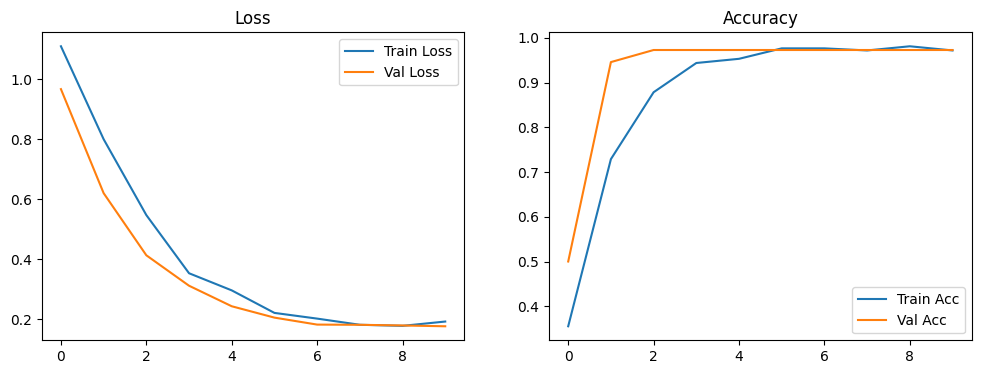

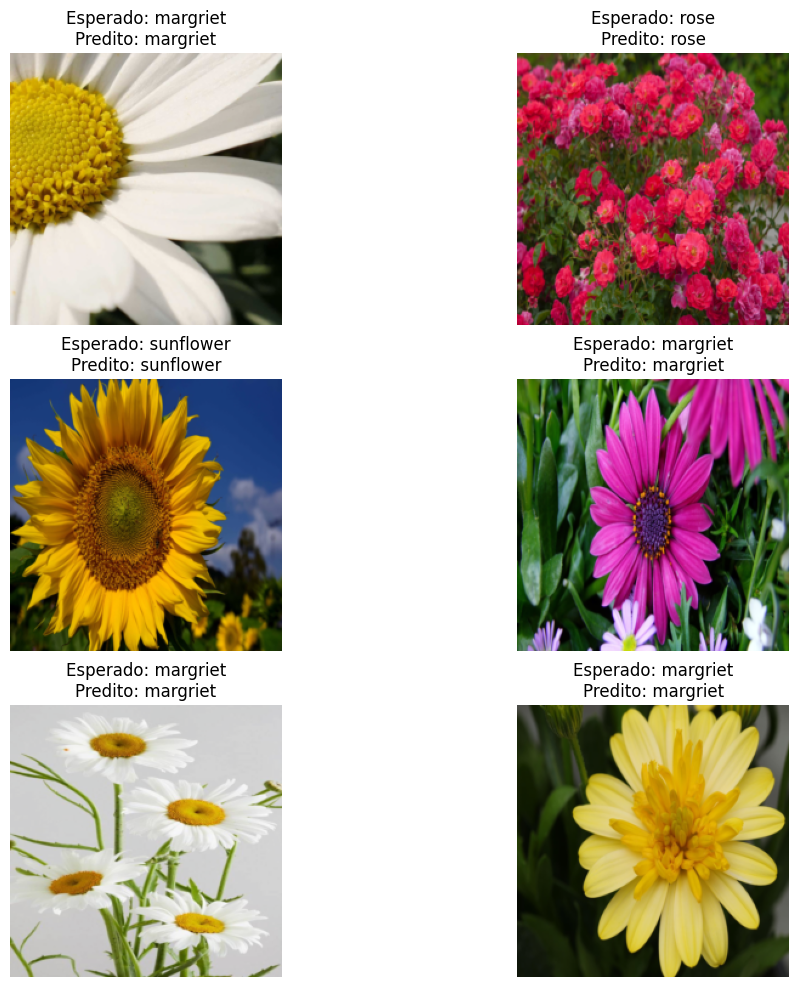

In [36]:
# Plotar curvas de Loss e Acurácia
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

# Função para visualizar predições
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(12, 12))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                # Modificação: Adiciona o rótulo esperado e predito ao título
                ax.set_title(f'Esperado: {class_names[labels[j]]}\nPredito: {class_names[preds[j]]}')

                # Desnormalizar para exibir
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

visualize_model(model_ft)
